# Code principal

### Imports

In [1]:
from __future__ import annotations

import os
os.system('cls' if os.name == 'nt' else 'clear')

import pandas as pd
from datetime import datetime, timedelta
import timeit
import sys
import numpy as np
import random
import multiprocessing as mp
from tqdm import tqdm
from typing import TypeVar
from enum import Enum
import matplotlib.pyplot as plt
from IPython.display import display
import importlib  # Pour recharger le module
pd.set_option('future.no_silent_downcasting', True)

# Limite le nombre de decimales
from decimal import Decimal, getcontext
getcontext().prec = 5

# Evite les messages d'erreur de pandas
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) 

# Note le temps de calcul
start = timeit.default_timer()
sys.setrecursionlimit(1500)

# Importation des autres script
from config import config as cf
# import elec_price_layer

def display_full(x):
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    pd.set_option('display.float_format', '{:20,.2f}'.format)
    pd.set_option('display.max_colwidth', None)
    display(x)
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')
    pd.reset_option('display.float_format')
    pd.reset_option('display.max_colwidth')


### Chemins

In [2]:
DATA_DIR = cf.PROJECT_ROOT / "data"
INPUT_PYTHON_DIR = DATA_DIR / "input_residential"
INPUT_GAMS_DIR = DATA_DIR / "input_national"
OUTPUT_GAMS_DIR = DATA_DIR / "Modele_chronologique"

DEMANDM_PATH = OUTPUT_GAMS_DIR / "demandM.csv"
DEMANDFOYER_PATH = INPUT_PYTHON_DIR / f"Demande Foyer-{cf.annee_conso_foyer}.csv"
PRODPV_PATH = INPUT_PYTHON_DIR / "dispo_python.csv"
PRODVALUES_PATH = OUTPUT_GAMS_DIR / "prodValues.csv"

BESSSOC_PATH = INPUT_GAMS_DIR / "bessSOC.csv"
ACHAT_PATH = INPUT_GAMS_DIR / "achat.csv"

### Paramètres

In [3]:
cf.PERIODS = 8736 # 
cf.annee_conso_foyer = 2021

cf.STO = True # Calcul stochastique ou pas (sur le solaire)
cf.PRECISION = 10 # Précision du calcul (1: unité, 10: dizième d'unité)
cf.NB_SEM = 52 # Nombre de semaines à modéliser

#  Caractéristiques batterie
cf.PV_capa = 2.800 # kWc
cf.BESS_OPEX = 0 # OPEX (epsilon déjà pris en compte)
cf.BESS_MAX_TEST = (0, 6, 10, 14) # (0, 6, 10, 14)  Les différentes capacités maximales des batteries que l'on teste (cohérent avec BESS_CAPEX)
cf.BESS_CAPEX = {0:0, 6:5300, 10:6400, 14:7500} # {0:0, 6:5300, 10:6400, 14:7500} € - Prix des Beem battery (kWh:€)
cf.BESS_CAPA = 6 # kWh
cf.BESS_PUISS = 3 # kW
cf.min_SOC = 0.2 # 20% de SOC minimal

# Données de consommation
cf.PROFIL_CONSO = 'RES11 (+ RES11WE)' # RES11 (+ RES11WE) | RES2 (+ RES5) | RES2WE | RES3 | RES4

# Calcul économique
cf.n = 15 # Durée de vie d'une batterie
cf.TA = 0.05 # Taux d'actualisation
cf.turpe = 0.06 # €/kWh
cf.taxes = 0.3 # % 

#  Définition des semaines-types par saison
cf.SEMAINES = {
    "hiver" : [list(range(72, 241)), []], 
    "printemps" : [list(range(2256, 2425)), []],
    "ete" : [list(range(4440, 4609)), []],
    "automne" : [list(range(6624, 6793)), []]
    }

cf.TRANSITION_MATRIX = {'p11_solar': 7.349472, 'p11_wind': 14.28572,
                     'p21_solar': -13.9232, 'p21_wind': -17.944}
cf.REGIME_1  = {'c': -6.06971624956,
                'rload': 6.98511187179e-05,
                'share_solar': -1.57793342889,
                'share_wind': -1.06511552798 }
cf.REGIME_2 = {'c': 2.63225434198,
               'rload': 3.2477216102e-05,
               'share_solar': -0.54220999006,
               'share_wind': -4.12400593849 }

# ----- Paramètres calculés automatiquement (à ne pas modifier) -----
cf.bess_opex = 0 + cf.EPSILON # OPEX
cf.BESS_CAPA = cf.BESS_CAPA * cf.PRECISION # kWh ou 10 kWh (dépendemment de la précision)
cf.BESS_CAPA = cf.BESS_CAPA * (1 - cf.min_SOC)
cf.BESS_PUISS = cf.BESS_PUISS * cf.PRECISION # kW ou 10 kWh (dépendemment de la précision)



### Importations données

In [4]:
df_dem = pd.read_csv(DEMANDFOYER_PATH, sep=';') # Demande
cf.DEM = df_dem[cf.PROFIL_CONSO].div(1000).round(2).tolist()
cf.DF_PV = pd.read_csv(PRODPV_PATH, sep=',') # Producion PV
cf.PV = (cf.DF_PV['dispo PV'] * cf.PV_capa).round(2) # Production PV = disponibilité nationale * Puissance PV résidentiel
cf.DF_PRODVALUES = pd.read_csv(PRODVALUES_PATH, sep=",", decimal =".").replace('"', '') # Production nationale PV et éolienne

### Prix de l'électricité

In [5]:
import electricity_price

def calcul_prix_elec(df_prodvalues, iterations) : 
    df_prodvalues["Rload"] = df_prodvalues["prod totale"] - df_prodvalues["prod PV"] - df_prodvalues["prod eolien"]
    df_prodvalues["share solar"] = df_prodvalues["prod PV"] / df_prodvalues["prod totale"]
    df_prodvalues["share wind"] = df_prodvalues["prod eolien"] / df_prodvalues["prod totale"]

    rload = df_prodvalues["Rload"].iloc[cf.SHIFT : cf.SHIFT + cf.DURATION].to_numpy()
    share_solar = df_prodvalues["share solar"].iloc[cf.SHIFT : cf.SHIFT + cf.DURATION].to_numpy()
    share_wind = df_prodvalues["share wind"].iloc[cf.SHIFT : cf.SHIFT + cf.DURATION].to_numpy()

    results = []

    for i in tqdm(range(iterations), total=iterations):
        result = electricity_price.run_iteration(rload, share_solar, share_wind)
        results.append(result)

    rows = [row for sublist in results for row in sublist]
    elecprice_df = (
        pd.DataFrame(rows)
        .groupby(["timestep"])
        .agg(
            {
                "timestep": "first",
                "regime": "mean",
                "price": "mean",
            }
        )
        .reset_index(drop=True)
    )

    return elecprice_df

# Paramètres calcul prix électricité

cf.HISTORIC_ELECTRICITY_PRICE = 32.2  # €/MWh
# cf.ITERATIONS = 1000
cf.DURATION = cf.PERIODS  # hours
cf.SHIFT = 0  # hours
cf.SEED = 42 # Seed pour le random
electricity_price.set_seed(cf.SEED)

# Importation données
df_prodvalues = pd.read_csv(PRODVALUES_PATH)

# Appel fonction
elecprice_df = calcul_prix_elec(df_prodvalues, iterations=1000)

display_full(elecprice_df)

cf.ELECPRICE = elecprice_df["price"].to_list()
print("Prix de l'électricité calculés : longueur = ", len(cf.ELECPRICE))

display_full(df_prodvalues[4000:4500])

100%|██████████| 1000/1000 [00:53<00:00, 18.54it/s]


,timestep,regime,price
0,0,1.50,58.42
1,1,1.50,56.20
2,2,1.53,57.14
3,3,1.51,52.84
4,4,1.52,51.40
5,5,1.51,50.50
6,6,1.49,50.11
7,7,1.53,51.72
8,8,1.50,51.00
9,9,1.52,52.10


Prix de l'électricité calculés : longueur =  8736


,periode,prod totale,prod PV,prod eolien,Rload,share solar,share wind
4000,4001,"52,640.00","4,892.16","1,163.65","46,584.19",0.09,0.02
4001,4002,"51,765.50","3,198.72","1,163.65","47,403.13",0.06,0.02
4002,4003,"51,948.00","1,693.44","1,163.65","49,090.91",0.03,0.02
4003,4004,"52,554.00",564.48,"1,396.38","50,593.14",0.01,0.03
4004,4005,"50,332.50",0.00,"2,094.57","48,237.93",0.00,0.04
4005,4006,"47,644.50",0.00,"2,792.76","44,851.74",0.00,0.06
4006,4007,"47,458.00",0.00,"3,956.41","43,501.59",0.00,0.08
4007,4008,"48,954.00",0.00,"5,352.79","43,601.21",0.00,0.11
4008,4009,"45,939.50",0.00,"5,818.25","40,121.25",0.00,0.13
4009,4010,"41,929.50",0.00,"5,818.25","36,111.25",0.00,0.14


### Modèle batterie

In [6]:
# df = behavior_layer.one_year_model(cf.BESS_CAPA)

In [7]:
import behavior_layer

print("BESS_CAPA = ", cf.BESS_CAPA)

# cf.DF = behavior_layer.weeks_behavior(cf.BESS_CAPA)
cf.DF = behavior_layer.annual_behavior(cf.BESS_CAPA)
df = cf.DF
print(f"Taille finale : {len(df)} lignes")

full_year_df = df

BESS_CAPA =  48.0
Semaine 1
Période: 0 à 166 (longueur: 168)
Modélisation simple du comportement d'un système PV-batterie
Modélisation intialisée
Semaine 2
Période: 168 à 334 (longueur: 168)
Modélisation simple du comportement d'un système PV-batterie
Modélisation intialisée
Semaine 3
Période: 336 à 502 (longueur: 168)
Modélisation simple du comportement d'un système PV-batterie
Modélisation intialisée
Semaine 4
Période: 504 à 670 (longueur: 168)
Modélisation simple du comportement d'un système PV-batterie
Modélisation intialisée
Semaine 5
Période: 672 à 838 (longueur: 168)
Modélisation simple du comportement d'un système PV-batterie
Modélisation intialisée
Semaine 6
Période: 840 à 1006 (longueur: 168)
Modélisation simple du comportement d'un système PV-batterie
Modélisation intialisée
Semaine 7
Période: 1008 à 1174 (longueur: 168)
Modélisation simple du comportement d'un système PV-batterie
Modélisation intialisée
Semaine 8
Période: 1176 à 1342 (longueur: 168)
Modélisation simple du c

### Exportations (pour GAMS)

In [8]:
# Exporter les valeurs d'injection provenant des BESS pour le modèle GAMS
full_year_df["SOC_injectee"] = (
    full_year_df.apply( lambda row:
        max(0, float(Decimal(str(row['Demande'])) + Decimal(str(row['Vente'])) - Decimal(str(row['Prod PV'])) - Decimal(str(row['Achat'])))),
        axis=1).round(2)) # opérations pour forcer l'arrondi
df_subset = full_year_df[["SOC_injectee"]].copy()
df_subset.index = df_subset.index + 1
df_subset.to_csv(BESSSOC_PATH, index=True, header=False)

# Exporter les valeurs d'achat d'électricité pour les BESS pour le modèle GAMS
full_year_df['Achat batterie'] = 0 #(full_year_df['Achat'] + full_year_df['Prod PV'] - full_year_df['Demande']).clip(lower=0)
df_subset = full_year_df[["Achat batterie"]].copy().round(3)
df_subset.index = df_subset.index + 1
df_subset.to_csv(ACHAT_PATH, index=True, header=False)

# Graphiques

### Ajouts colonnes

In [9]:
col_ajoutee = ("SOC_charge", "SOC_decharge", "Achat_t", "Well_0")
# Supprimer les colonnes ajoutées si elles existent déjà pour éviter les problèmes
for col in col_ajoutee : 
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Configurer la précision
getcontext().prec = 4  # 4 chiffres significatifs

# Appliquer aux données
df["Well"] = df["Well"].apply(lambda x: float(Decimal(str(x)).quantize(Decimal('0.001'))))
df["SOC_decharge"] = (df["Demande"] + df["Vente"] - df["Prod PV"] - df["Achat"]).clip(lower=0).round(3)
df["Achat_t"] = (df["Demande"] - df["Prod PV"] - df["SOC_t"]).clip(lower=0)
df["Well_0"] = (df["Prod PV"] - df["Demande"] - df["Vente"]).clip(lower=0).round(3)

In [10]:
display_full(df[3835:4500])

,Saison,Date,Heure,Demande,Prod PV,SOC_t,Vente,Achat,Well,Prix elec,SOC_injectee,Achat batterie,SOC_decharge,Achat_t,Well_0
3835,23,6/9/2021,19,0.39,0.11,1.70,0.00,0.00,0.02,46.70,0.28,0,0.28,0.00,0.00
3836,23,6/9/2021,20,0.37,0.00,1.40,0.00,0.00,0.03,43.50,0.37,0,0.37,0.00,0.00
3837,23,6/9/2021,21,0.34,0.00,1.00,0.00,0.00,0.06,40.44,0.34,0,0.34,0.00,0.00
3838,23,6/9/2021,22,0.30,0.00,0.60,0.00,0.00,0.00,39.06,0.30,0,0.30,0.00,0.00
3839,23,6/9/2021,23,0.26,0.00,0.30,0.00,0.00,0.04,41.05,0.26,0,0.26,0.00,0.00
3840,23,6/10/2021,0,0.22,0.00,0.00,0.00,0.22,0.00,38.52,0.00,0,0.00,0.22,0.00
3841,23,6/10/2021,1,0.19,0.00,0.00,0.00,0.19,0.00,36.33,0.00,0,0.00,0.19,0.00
3842,23,6/10/2021,2,0.18,0.00,0.00,0.00,0.18,0.00,35.38,0.00,0,0.00,0.18,0.00
3843,23,6/10/2021,3,0.18,0.00,0.00,0.00,0.18,0.00,33.40,0.00,0,0.00,0.18,0.00
3844,23,6/10/2021,4,0.18,0.00,0.00,0.00,0.18,0.00,30.65,0.00,0,0.00,0.18,0.00


### Affichage prix de l'électricité

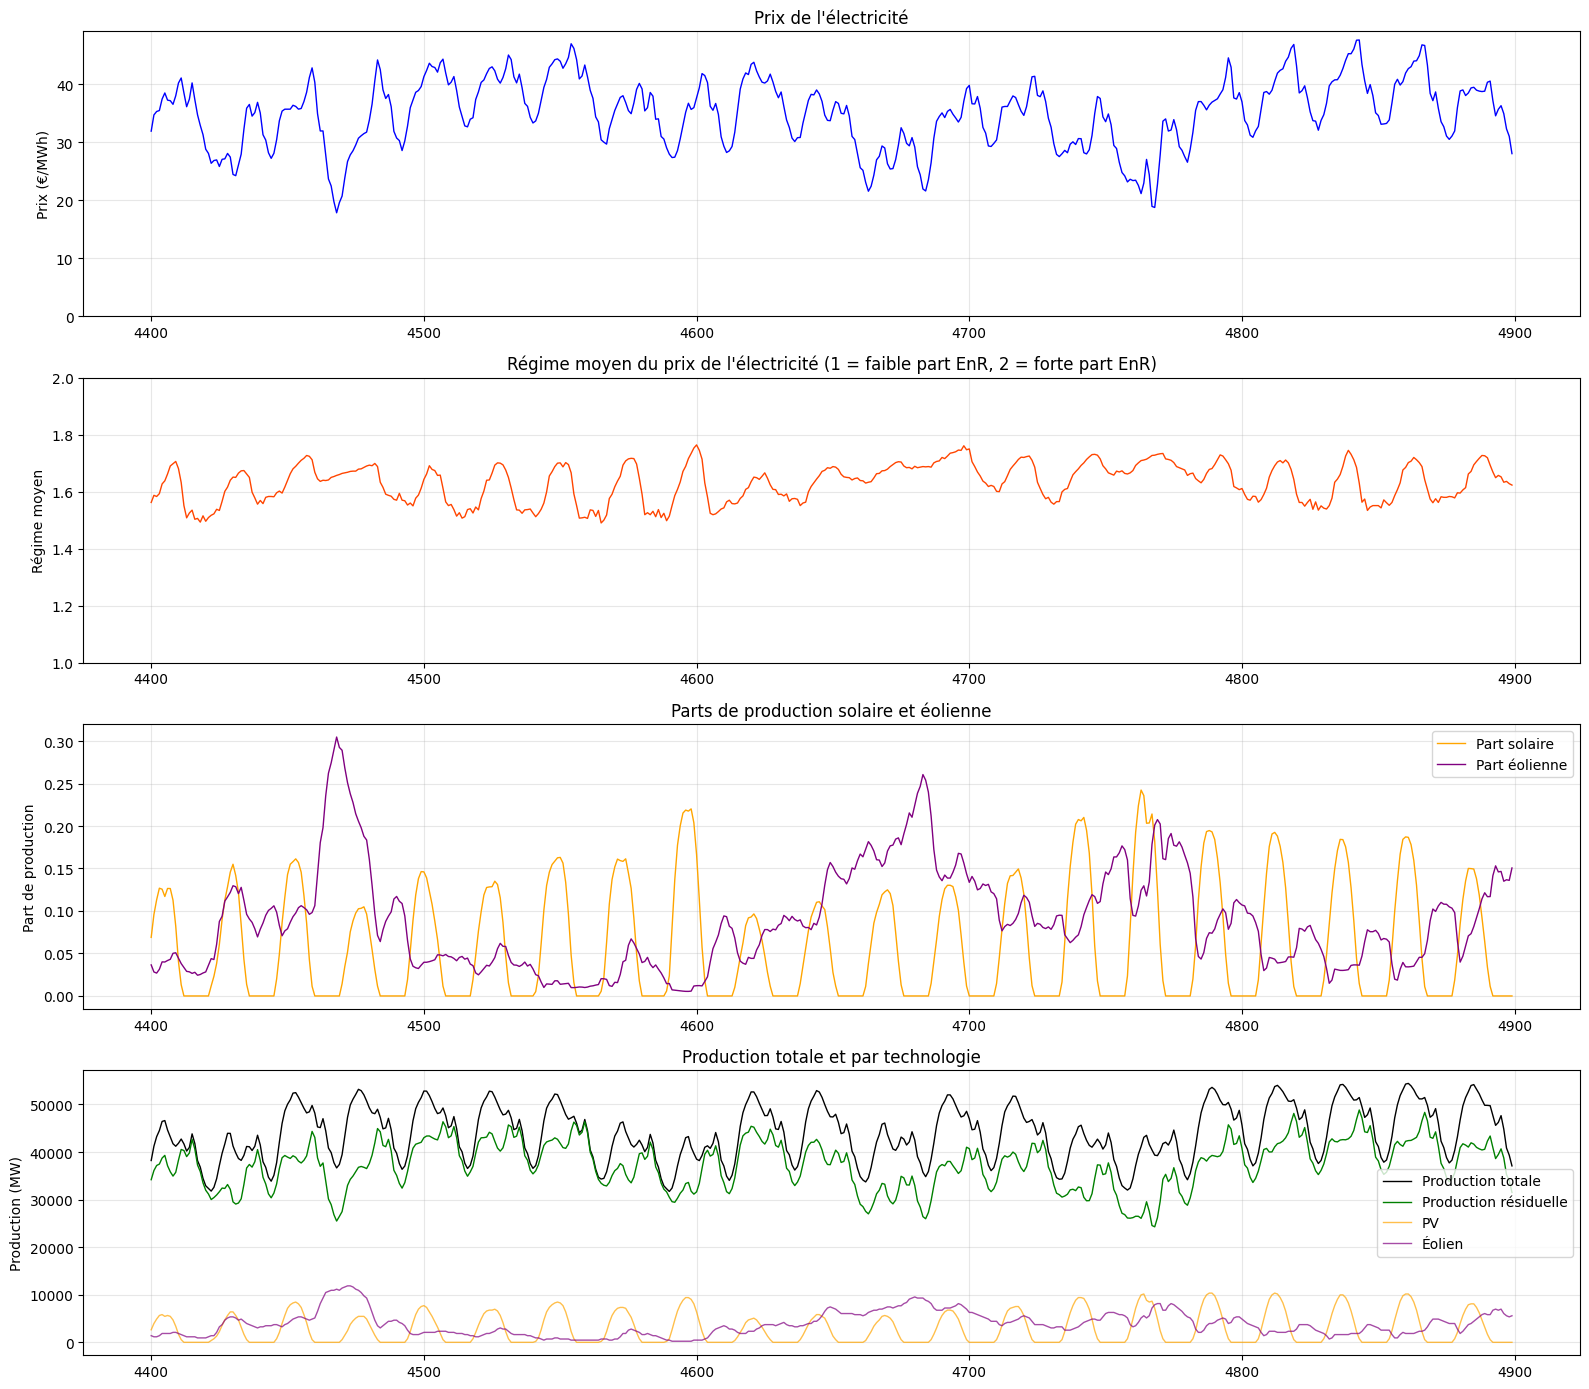

In [11]:
def plot_elec_price(df_results, x_range=(4400, 4900)):
    """
    Fonction pour tracer les résultats de la simulation des prix de l'électricité.
    Affiche les prix simulés, les parts de production solaire et éolienne, 
    la production totale et les régimes de prix.
    """

    df_results = df_results.iloc[x_range[0]:x_range[1]].copy()

    # Création des graphiques
    fig, axes = plt.subplots(4, 1, figsize=(16, 14))

    axes[0].plot(df_results.index, df_results['Prix_simule'], color='blue', linewidth=1)
    axes[0].set_ylabel('Prix (€/MWh)')
    axes[0].set_title('Prix de l\'électricité')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(bottom=0)

    # 2. Regime de prix de l'électricité
    axes[1].plot(df_results.index, df_results['Regime prix'], color='orangered', linewidth=1)
    axes[1].set_ylabel('Régime moyen')
    axes[1].set_title('Régime moyen du prix de l\'électricité (1 = faible part EnR, 2 = forte part EnR)')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(bottom=1, top=2)

    # 3. Production solaire et éolienne
    axes[2].plot(df_results.index, df_results['share solar'], color='orange', label='Part solaire', linewidth=1)
    axes[2].plot(df_results.index, df_results['share wind'], color='purple', label='Part éolienne', linewidth=1)
    axes[2].set_ylabel('Part de production')
    axes[2].set_title('Parts de production solaire et éolienne')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # 4. Production totale et composantes
    axes[3].plot(df_results.index, df_results['prod totale'], color='black', label='Production totale', linewidth=1)
    axes[3].plot(df_results.index, df_results['Rload'], color='green', label='Production résiduelle', linewidth=1)
    axes[3].plot(df_results.index, df_results['prod PV'], color='orange', label='PV', linewidth=1, alpha=0.7)
    axes[3].plot(df_results.index, df_results['prod eolien'], color='purple', label='Éolien', linewidth=1, alpha=0.7)
    axes[3].set_ylabel('Production (MW)')
    axes[3].set_title('Production totale et par technologie')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame({
    'Prix_simule': elecprice_df['price'],
    'Regime prix': elecprice_df["regime"],
    'prod totale': df_prodvalues['prod totale'],
    'prod PV': df_prodvalues['prod PV'],
    'prod eolien': df_prodvalues['prod eolien'],
    'share solar': df_prodvalues['share solar'],
    'share wind': df_prodvalues['share wind'], 
    'Rload': df_prodvalues['Rload']
})

plot_elec_price(df_results)

### Comportement de la batterie

In [12]:
def heure_vers_date(heure_année: int):
    """Convertit une heure de l'année (1-8760) en date"""
    # Début de l'année (1er janvier à 00:00)
    debut_année = datetime(datetime.now().year, 1, 1)
    # Ajouter les heures (heure-1 car l'heure 1 correspond à 00:00-01:00)
    date = debut_année + timedelta(hours=heure_année-1)
    return date.strftime("%d %B")

week = 168 * 25


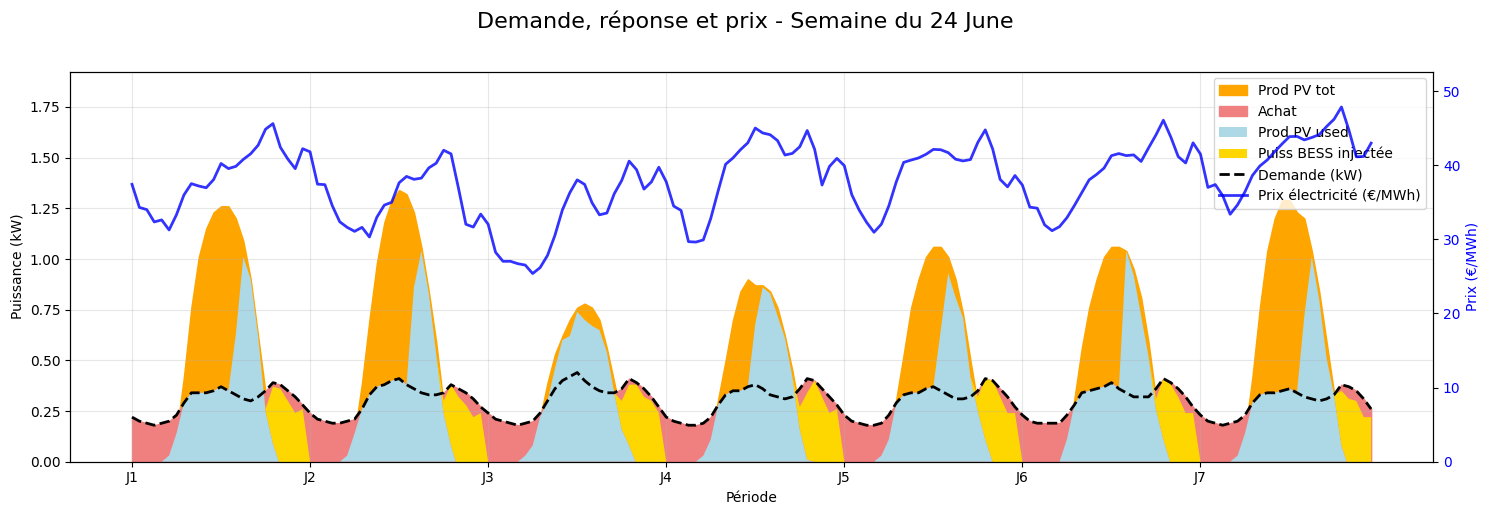

In [13]:
def plot_period_day_well(df, period: list, elec_prices, week):
    """
    Affiche un graphique détaillé pour une période spécifique
    """
    start_period, end_period = period
    
    # Filtrer le DataFrame pour la plage de périodes sélectionnée
    filtered_df = df[(df.index >= start_period) & (df.index <= end_period)].copy()
    
    # Créer une seule figure
    fig, ax_power = plt.subplots(1, 1, figsize=(15, 5))
    fig.suptitle(f"Demande, réponse et prix - Semaine du {week}", y=1.02, fontsize=16)
    # fig.suptitle(f"Demande, réponse et prix - Période {start_period} à {end_period}", y=1.02, fontsize=16)
    
    # Déterminer les limites des axes Y
    y_max_power = filtered_df[["Demande", "Prod PV", "SOC_decharge"]].sum(axis=1).max() * 1.1
    y_max_price = max(elec_prices[start_period:end_period + 1]) * 1.1
    
    # Nettoyage des données
    filtered_df["Prod PV"] = filtered_df["Prod PV"].fillna(0).astype(float)
    filtered_df["SOC_decharge"] = filtered_df["SOC_decharge"].fillna(0).astype(float)
    
    # Récupérer les prix pour cette période
    period_prices = elec_prices[start_period:end_period + 1]
    
    # Créer l'axe secondaire pour les prix
    ax_price = ax_power.twinx()
    
    # === AXE PRINCIPAL (Puissance) ===
    # Utiliser les index réels pour l'axe x
    x_values = filtered_df.index
    
    ax_power.fill_between(x_values, filtered_df["Prod PV"], label="Prod PV tot", color="orange", alpha=1)
    ax_power.fill_between(x_values, filtered_df["Demande"], label="Achat", color="lightcoral", alpha=1)
    
    ax_power.stackplot(x_values,
                      filtered_df["Prod PV"] - filtered_df["Well"].round(3),
                      filtered_df["SOC_decharge"],
                      labels=["Prod PV used", "Puiss BESS injectée"],
                      colors=["lightblue", "gold"],
                      alpha=1)
    
    ax_power.plot(x_values, filtered_df["Demande"], label="Demande (kW)", color="black", linestyle='--', linewidth=2)
    
    # === AXE SECONDAIRE (Prix) ===
    ax_price.plot(x_values, period_prices, label="Prix électricité (€/MWh)", color="blue", linewidth=2, alpha=0.8)
    
    # Configuration des ticks - adaptée à la longueur de la période
    periode_length = len(filtered_df)
    
    if periode_length <= 24:  # 1 jour ou moins
        # Ticks toutes les 3 heures
        ticks_positions = list(range(start_period, end_period + 1, 3))
        ax_power.set_xticks(ticks_positions)
        ax_power.set_xticklabels([f"{h%24}h" for h in ticks_positions])
        
    elif periode_length <= 168:  # 1 semaine ou moins
        # Ticks tous les jours
        ticks_positions = list(range(start_period, end_period + 1, 24))
        ax_power.set_xticks(ticks_positions)
        jours_semaine = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
        ax_power.set_xticklabels([f"J{i+1}" for i in range(len(ticks_positions))])
        
    else:  # Plus d'une semaine
        # Ticks tous les 2-3 jours
        ticks_positions = list(range(start_period, end_period + 1, 48))  # Tous les 2 jours
        ax_power.set_xticks(ticks_positions)
        ax_power.set_xticklabels([f"Jour {(pos-start_period)//24 + 1}" for pos in ticks_positions])
    
    # Paramètres des axes
    ax_power.set_xlabel("Période")
    ax_power.set_ylabel("Puissance (kW)", color='black')
    ax_power.set_ylim(0, y_max_power)
    ax_power.tick_params(axis='y', labelcolor='black')
    ax_power.grid(True, alpha=0.3)
    
    ax_price.set_ylabel("Prix (€/MWh)", color='blue')
    ax_price.set_ylim(0, y_max_price)
    ax_price.tick_params(axis='y', labelcolor='blue')
    
    # Légendes combinées
    lines1, labels1 = ax_power.get_legend_handles_labels()
    lines2, labels2 = ax_price.get_legend_handles_labels()
    ax_power.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.tight_layout()
    plt.show()

plot_period_day_well(df, [week,week+167], cf.ELECPRICE, heure_vers_date(week))


### SOC de la batterie

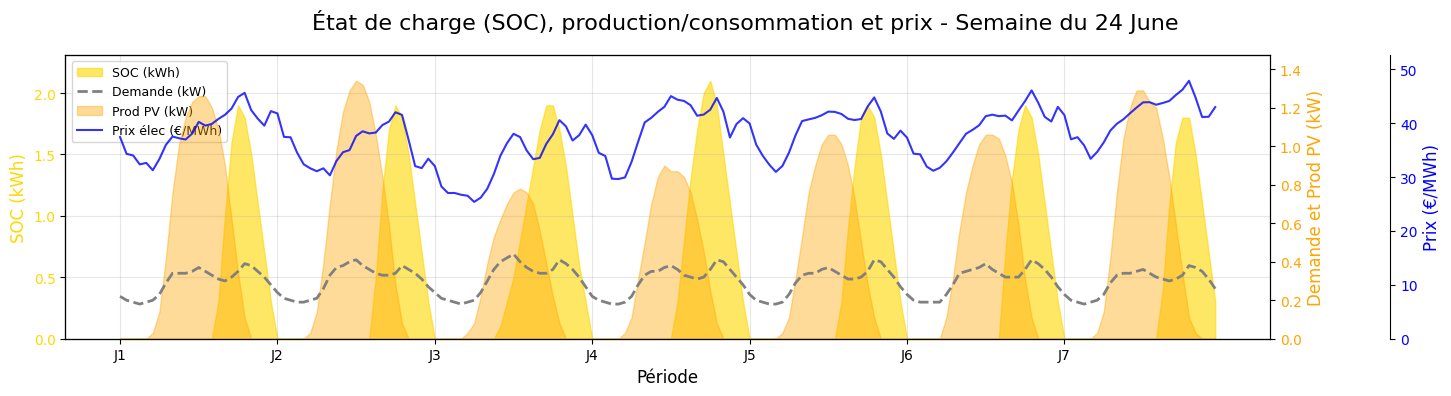

In [14]:
def plot_period_soc_vertical(df, period: list, elec_prices, week):
    """
    Affiche un graphique vertical avec SOC, production/consommation et prix pour une période spécifique
    """
    start_period, end_period = period
    
    # Filtrer le DataFrame pour la plage de périodes sélectionnée
    filtered_df = df[(df.index >= start_period) & (df.index <= end_period)].copy()
    
    # Créer une seule figure
    fig, ax1 = plt.subplots(1, 1, figsize=(15, 4))
    fig.suptitle(f"État de charge (SOC), production/consommation et prix - Semaine du {week}", y=0.98, fontsize=16)
    # fig.suptitle(f"État de charge (SOC), production/consommation et prix - Période {start_period} à {end_period}", y=0.98, fontsize=16)
    
    # Déterminer les limites des axes Y
    soc_max = filtered_df["SOC_t"].max() * 1.1
    demand_pv_max = max(filtered_df["Demande"].max(), filtered_df["Prod PV"].max()) * 1.1
    price_max = max(elec_prices[start_period:end_period + 1]) * 1.1
    
    # Récupérer les prix pour cette période
    period_prices = elec_prices[start_period:end_period + 1]
    
    # Premier axe Y (SOC) - Gauche
    ax1.fill_between(filtered_df.index, filtered_df["SOC_t"], label="SOC (kWh)", color="gold", alpha=0.6)
    ax1.set_ylabel("SOC (kWh)", fontsize=12, color="gold")
    ax1.tick_params(axis='y', labelcolor="gold")
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, soc_max)
    
    # Deuxième axe Y (Demande et Prod PV) - Droite
    ax2 = ax1.twinx()
    ax2.plot(filtered_df.index, filtered_df["Demande"], label="Demande (kW)", linestyle='--', color="grey", linewidth=2)
    ax2.fill_between(filtered_df.index, filtered_df["Prod PV"], label="Prod PV (kW)", color="orange", alpha=0.4)
    ax2.set_ylabel("Demande et Prod PV (kW)", fontsize=12, color="orange")
    ax2.tick_params(axis='y', labelcolor="orange")
    ax2.set_ylim(0, demand_pv_max)
    
    # Troisième axe Y (Prix) - Droite, décalé
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.1))  # Décaler le troisième axe
    ax3.plot(filtered_df.index, period_prices, label="Prix élec (€/MWh)", color="blue", linewidth=1.5, alpha=0.8)
    ax3.set_ylabel("Prix (€/MWh)", fontsize=12, color="blue")
    ax3.tick_params(axis='y', labelcolor="blue")
    ax3.set_ylim(0, price_max)
    
    # Configuration des ticks - adaptée à la longueur de la période
    periode_length = len(filtered_df)
    
    if periode_length <= 24:  # 1 jour ou moins
        # Ticks toutes les 3 heures
        ticks_positions = list(range(start_period, end_period + 1, 3))
        ax1.set_xticks(ticks_positions)
        ax1.set_xticklabels([f"{h%24}h" for h in ticks_positions])
        
    elif periode_length <= 168:  # 1 semaine ou moins
        # Ticks tous les jours
        ticks_positions = list(range(start_period, end_period + 1, 24))
        ax1.set_xticks(ticks_positions)
        ax1.set_xticklabels([f"J{i+1}" for i in range(len(ticks_positions))])
        
    else:  # Plus d'une semaine
        # Ticks tous les 2-3 jours
        ticks_positions = list(range(start_period, end_period + 1, 48))  # Tous les 2 jours
        ax1.set_xticks(ticks_positions)
        ax1.set_xticklabels([f"Jour {(pos-start_period)//24 + 1}" for pos in ticks_positions])
    
    # Paramètres du graphique
    ax1.set_xlabel("Période", fontsize=12)
    
    # Combiner les légendes des trois axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc="upper left", fontsize=9)
    
    # Ajuster l'espacement pour l'axe décalé
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    plt.show()

plot_period_soc_vertical(df, [week,week+167], cf.ELECPRICE, heure_vers_date(week))

### KPI

In [15]:
# Définir une fonction pour déterminer la saison à partir de l'heure de l'année
def heure_vers_saison(heure_année):
    jour_année = (heure_année - 1) // 24  # Convertir l'heure en jour (0-365)
    
    # Définir les saisons (approximatif)
    if 79 <= jour_année <= 171:    # 20 mars - 20 juin
        return "Printemps"
    elif 172 <= jour_année <= 264:  # 21 juin - 22 septembre
        return "Été"
    elif 265 <= jour_année <= 355:  # 23 septembre - 21 décembre
        return "Automne"
    else:                           # 22 décembre - 19 mars
        return "Hiver"

# Appliquer la fonction pour créer une colonne saison
elecprice_df['saison'] = elecprice_df.index.map(heure_vers_saison)
df['saison'] = elecprice_df.index.map(heure_vers_saison)

In [16]:
# # print(df.head)
# print("Total énergie déchargée par les batteries : ", round( df["SOC_injectee"].sum(), 2), "kWh")
# print("Total well : ", round( df["Well"].sum(), 2), "kWh")
# print("Total prod PV : ", round( df["Prod PV"].sum(), 2), "kWh")
# print("Régime moyen : ", round( elecprice_df["regime"].mean(), 2))

# # Calculer le régime moyen par saison
# regime_moyen_par_saison = elecprice_df.groupby('saison')['regime'].mean()

# print("Régime moyen par saison :")
# for saison, moyenne in regime_moyen_par_saison.items():
#     print(f" - {saison}: {moyenne:.2f}")

# Fusionner
df_combined = df.copy()
df_combined['price'] = elecprice_df['price']
df_combined['regime'] = elecprice_df['regime']

# Calculer tous les KPIs en une fois
df_kpis = df_combined.groupby('saison').agg({
    'Prod PV': 'sum',
    'Well': 'sum',
    'SOC_injectee': 'sum',
    'price': 'mean',
    'regime': 'mean'
}).rename(columns={
    'Prod PV': 'Prod PV totale (kWh)',
    'Well': 'Ecrêtement total (kWh)',
    'SOC_injectee': 'Energie batteries (kWh)',
    'price': 'Prix moyen (€/MWh)',
    'regime': 'Régime moyen'
})

# Ajouter le ratio
df_kpis['Ratio well/PV (%)'] = ( df_kpis['Ecrêtement total (kWh)'] / df_kpis['Prod PV totale (kWh)'] ) * 100

print("KPIs par saison :")
display_full(df_kpis.round(2))
# print(df_kpis.round(2))

KPIs par saison :


,Prod PV totale (kWh),Ecrêtement total (kWh),Energie batteries (kWh),Prix moyen (€/MWh),Régime moyen,Ratio well/PV (%)
saison,,,,,,
Automne,460.05,52.08,96.32,44.54,1.59,11.32
Hiver,332.62,8.52,33.99,48.33,1.60,2.56
Printemps,892.36,236.71,200.42,37.80,1.62,26.53
Été,873.02,330.65,169.91,35.03,1.61,37.87


### National

In [25]:
RESULTS_DIR = cf.PROJECT_ROOT / "data" / "Modele_chronologique" / "results.csv"

df_nat = pd.read_csv(RESULTS_DIR, delimiter=',') 
display(df_nat.iloc[4046:4500])
print("Différence brute/nette = ", df_nat["demande brute"].sum() - df_nat["demande nette"].sum())

,periode,demande brute,demande nette
4046,4047,52137.0,52137.0
4047,4048,50983.5,50983.5
4048,4049,49644.5,49644.5
4049,4050,48670.5,48670.5
4050,4051,48709.0,48639.0
...,...,...,...
4495,4496,42745.5,42745.5
4496,4497,46568.0,46568.0
4497,4498,49102.0,49102.0
4498,4499,50435.5,50435.5


Différence brute/nette =  500640.0


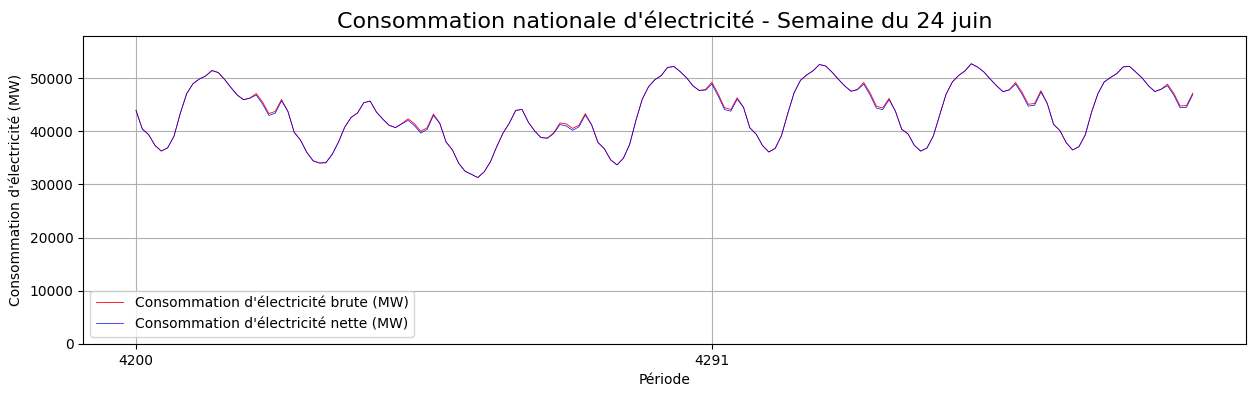

In [26]:
def graph(period, week) : 
    start_period, end_period = period
    # Filtrer le DataFrame pour la plage de périodes sélectionnée
    filtered_df = df_nat[(df_nat.index >= start_period) & (df_nat.index <= end_period)].copy()

    # Créer le graphique
    plt.figure(figsize=(15, 4))
    
    plt.plot(filtered_df.index, filtered_df["demande brute"], label="Consommation d'électricité brute (MW)", color="red", linewidth=0.6)
    plt.plot(filtered_df.index, filtered_df["demande nette"], label="Consommation d'électricité nette (MW)", color="blue", linewidth=0.5)

    # Ajouter labels, titre, légende, grille
    plt.xlabel("Période")
    plt.ylabel("Consommation d'électricité (MW)")
    plt.title(f"Consommation nationale d'électricité - Semaine du {week}", fontsize=16)
    # plt.title(f"Consommation nationale d'électricité (Périodes {start_period} à {end_period})")
    plt.xticks(range(start_period, end_period + 1, 91))  # Tics toutes les 3 périodes
    plt.ylim(0, filtered_df["demande brute"].max()*1.1)
    plt.legend()
    plt.grid(True)

    plt.show()

graph((week, week+167), heure_vers_date(week))

### Nouveau calcul du prix de l'électricité

In [ ]:
# Importation données
# df_prodvalues = pd.read_csv(PRODVALUES_PATH)


df_prodvalues_new = df_prodvalues.copy()
df_prodvalues_new["prod totale"] = df_nat["demande nette"]

display_full(df_prodvalues_new[4046:4500])

# Appel fonction
elecprice_df_new = calcul_prix_elec(df_prodvalues_new, iterations=1000)

df_prodvalues["demande nette"] = df_prodvalues["prod totale"]
df_prodvalues["prod totale"] = df_nat["demande brute"]
df_prodvalues["Rload nette"] = df_prodvalues["demande nette"] - df_prodvalues["prod PV"] - df_prodvalues["prod eolien"]

# elecprice_df_original = calcul_prix_elec(df_prodvalues, iterations=1000)


,periode,prod totale,prod PV,prod eolien,Rload,share solar,share wind,demande nette,Rload nette
4046,4047,"52,137.00","7,526.40","7,912.82","36,697.78",0.14,0.15,"52,137.00","36,697.78"
4047,4048,"50,983.50","6,773.76","8,145.55","36,064.19",0.13,0.16,"50,983.50","36,064.19"
4048,4049,"49,644.50","5,456.64","7,912.82","36,275.04",0.11,0.16,"49,644.50","36,275.04"
4049,4050,"48,670.50","3,763.20","7,214.63","37,692.67",0.08,0.15,"48,670.50","37,692.67"
4050,4051,"48,709.00","1,881.60","6,050.98","40,776.42",0.04,0.12,"48,709.00","40,776.42"
4051,4052,"48,828.50",752.64,"4,654.60","43,421.26",0.02,0.10,"48,828.50","43,421.26"
4052,4053,"47,022.50",0.00,"4,189.14","42,833.36",0.00,0.09,"47,022.50","42,833.36"
4053,4054,"44,853.00",0.00,"4,189.14","40,663.86",0.00,0.09,"44,853.00","40,663.86"
4054,4055,"45,173.00",0.00,"4,189.14","40,983.86",0.00,0.09,"45,173.00","40,983.86"
4055,4056,"47,204.00",0.00,"3,956.41","43,247.59",0.00,0.08,"47,204.00","43,247.59"


100%|██████████| 1000/1000 [00:53<00:00, 18.76it/s]


In [20]:
display_full(df_prodvalues[4046:4500])

print("Prix moyen original : ", round(elecprice_df["price"].mean(), 2), "€")
print("Prix moyen new : ", round(elecprice_df_new["price"].mean(), 2), "€")

,periode,prod totale,prod PV,prod eolien,Rload,share solar,share wind,demande nette,Rload nette
4046,4047,"52,137.00","7,526.40","7,912.82","36,697.78",0.14,0.15,"52,137.00","36,697.78"
4047,4048,"50,983.50","6,773.76","8,145.55","36,064.19",0.13,0.16,"50,983.50","36,064.19"
4048,4049,"49,644.50","5,456.64","7,912.82","36,275.04",0.11,0.16,"49,644.50","36,275.04"
4049,4050,"48,670.50","3,763.20","7,214.63","37,692.67",0.08,0.15,"48,670.50","37,692.67"
4050,4051,"48,709.00","1,881.60","6,050.98","40,776.42",0.04,0.12,"48,709.00","40,776.42"
4051,4052,"48,828.50",752.64,"4,654.60","43,421.26",0.02,0.10,"48,828.50","43,421.26"
4052,4053,"47,022.50",0.00,"4,189.14","42,833.36",0.00,0.09,"47,022.50","42,833.36"
4053,4054,"44,853.00",0.00,"4,189.14","40,663.86",0.00,0.09,"44,853.00","40,663.86"
4054,4055,"45,173.00",0.00,"4,189.14","40,983.86",0.00,0.09,"45,173.00","40,983.86"
4055,4056,"47,204.00",0.00,"3,956.41","43,247.59",0.00,0.08,"47,204.00","43,247.59"


Prix moyen original :  41.29 €
Prix moyen new :  41.31 €


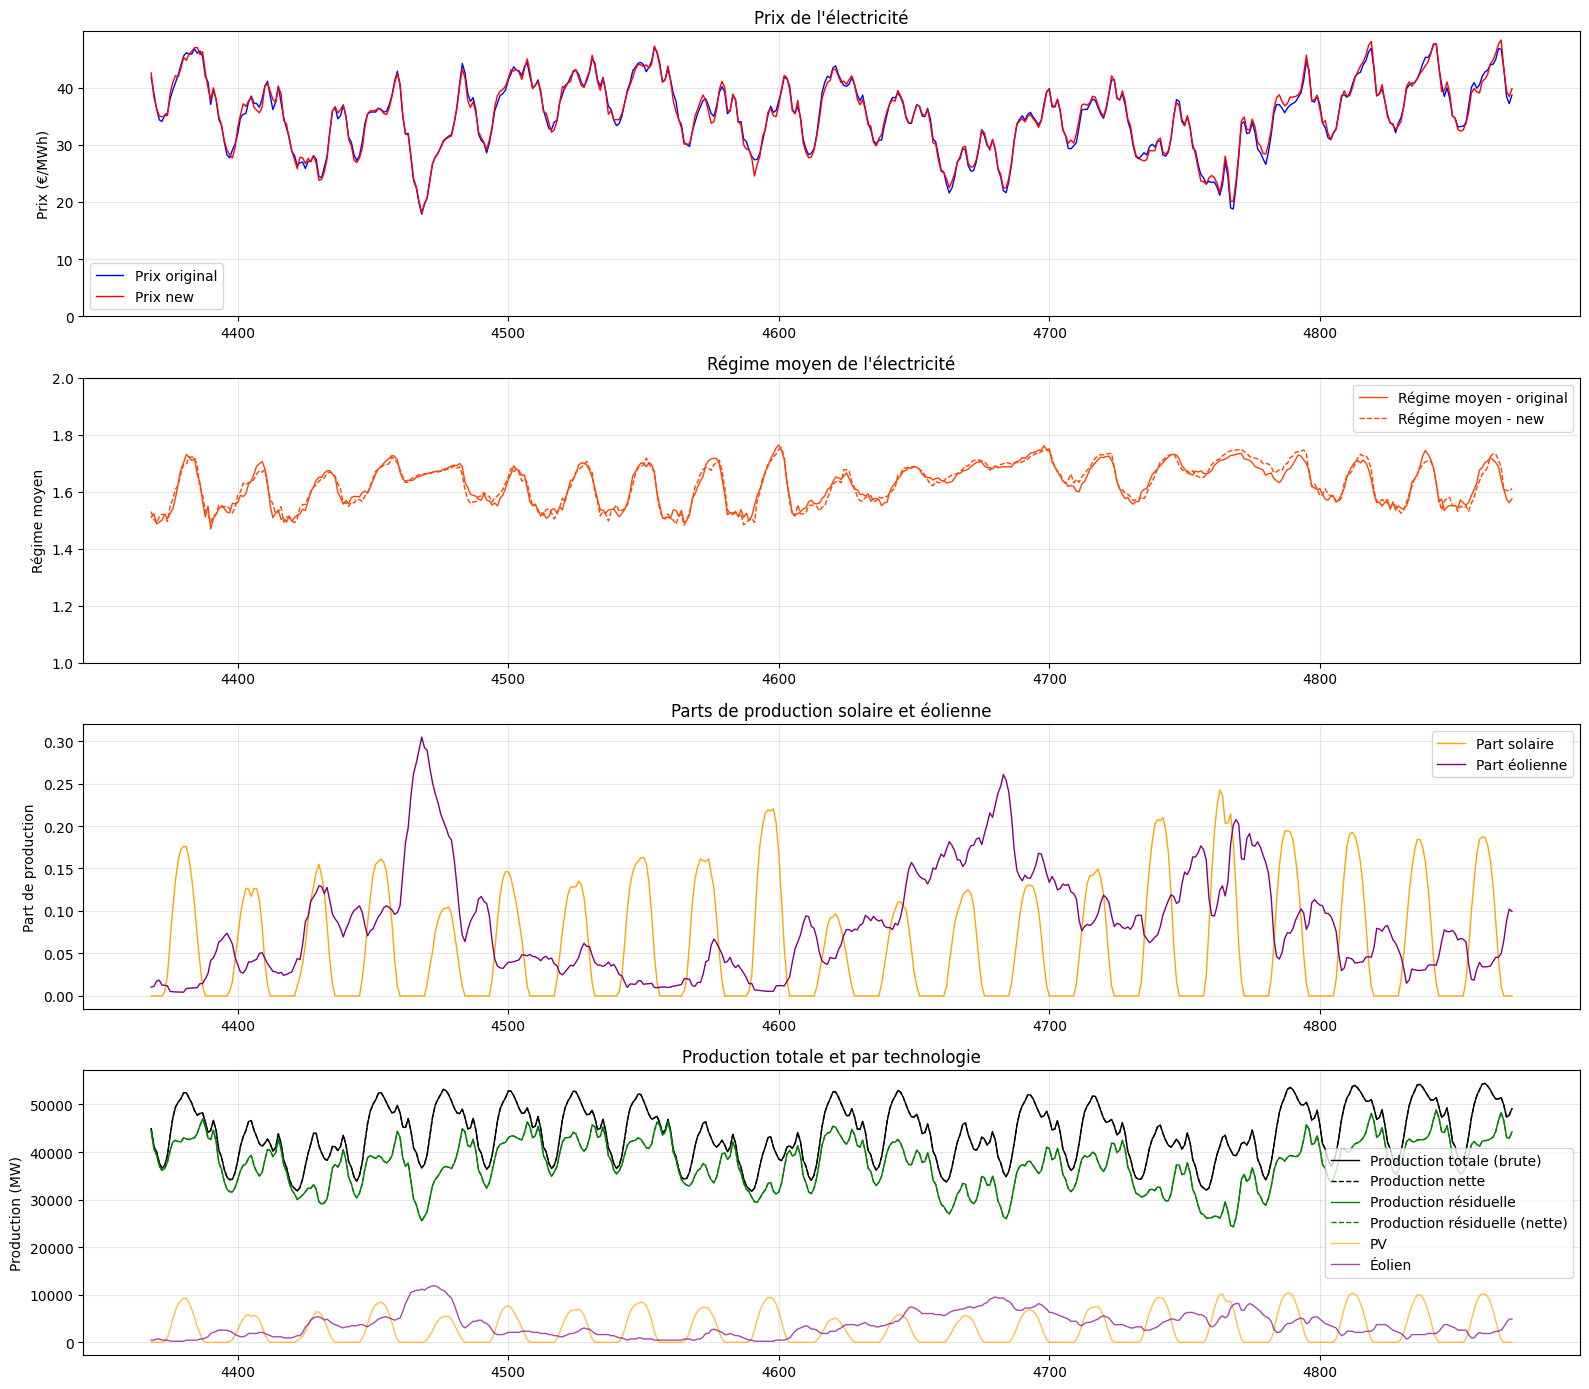

In [21]:
def plot_elec_price_comparaison(df_results, debut_sem, nb_sem):
    """
    Fonction pour tracer les résultats de la simulation des prix de l'électricité.
    Affiche les prix simulés, les parts de production solaire et éolienne, 
    la production totale et les régimes de prix.
    """

    debut = debut_sem * 168
    fin = debut + nb_sem * 168

    df_results = df_results.iloc[debut:fin].copy()

    # Création des graphiques
    fig, axes = plt.subplots(4, 1, figsize=(16, 14))

    axes[0].plot(df_results.index, df_results['Prix original'], color='blue', label="Prix original", linewidth=1)
    axes[0].plot(df_results.index, df_results['Prix new'], color='red', label="Prix new", linewidth=1)
    axes[0].set_ylabel('Prix (€/MWh)')
    axes[0].set_title('Prix de l\'électricité')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(bottom=0)

    axes[1].plot(df_results.index, df_results['Regime original'], color='orangered', label="Régime moyen - original", linewidth=1)
    axes[1].plot(df_results.index, df_results['Regime new'], color='orangered', label="Régime moyen - new", linewidth=1, linestyle="--")
    axes[1].set_ylabel('Régime moyen')
    axes[1].set_title('Régime moyen de l\'électricité')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(bottom=1, top=2)

    # 2. Production solaire et éolienne
    axes[2].plot(df_results.index, df_results['share solar'], color='orange', label='Part solaire', linewidth=1)
    axes[2].plot(df_results.index, df_results['share wind'], color='purple', label='Part éolienne', linewidth=1)
    axes[2].set_ylabel('Part de production')
    axes[2].set_title('Parts de production solaire et éolienne')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # 3. Production totale et composantes
    axes[3].plot(df_results.index, df_results['prod totale'], color='black', label='Production totale (brute)', linewidth=1)
    axes[3].plot(df_results.index, df_results['demande nette'], color='black', label='Production nette', linewidth=1, linestyle="--")
    axes[3].plot(df_results.index, df_results['Rload'], color='green', label='Production résiduelle', linewidth=1)
    axes[3].plot(df_results.index, df_results['Rload nette'], color='green', label='Production résiduelle (nette)', linewidth=1, linestyle="--")
    axes[3].plot(df_results.index, df_results['prod PV'], color='orange', label='PV', linewidth=1, alpha=0.7)
    axes[3].plot(df_results.index, df_results['prod eolien'], color='purple', label='Éolien', linewidth=1, alpha=0.7)
    axes[3].set_ylabel('Production (MW)')
    axes[3].set_title('Production totale et par technologie')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


df_results = pd.DataFrame({
    'Prix original': elecprice_df['price'],
    'Prix new': elecprice_df_new['price'],
    'Regime original': elecprice_df['regime'],
    'Regime new': elecprice_df_new['regime'],
    'prod totale': df_prodvalues['prod totale'],
    'demande nette': df_prodvalues['demande nette'],
    'prod PV': df_prodvalues['prod PV'],
    'prod eolien': df_prodvalues['prod eolien'],
    'share solar': df_prodvalues['share solar'],
    'share wind': df_prodvalues['share wind'], 
    'Rload': df_prodvalues['Rload'],
    'Rload nette': df_prodvalues['Rload nette'],
})

debut_sem = int(week / 168)
debut_sem = int(4400/168)
plot_elec_price_comparaison(df_results, debut_sem=debut_sem, nb_sem=3)

In [22]:
# Fusionner
df_combined = df.copy()
df_combined['price'] = elecprice_df_new['price']
df_combined['regime'] = elecprice_df_new['regime']

# Calculer tous les KPIs en une fois
df_kpis = df_combined.groupby('saison').agg({
    'Prod PV': 'sum',
    'Well': 'sum',
    'SOC_injectee': 'sum',
    'price': 'mean',
    'regime': 'mean'
}).rename(columns={
    'Prod PV': 'Prod PV totale (kWh)',
    'Well': 'Ecrêtement total (kWh)',
    'SOC_injectee': 'Energie batteries (kWh)',
    'price': 'Prix moyen (€/MWh)',
    'regime': 'Régime moyen'
})

# Ajouter le ratio
df_kpis['Ratio well/PV (%)'] = ( df_kpis['Ecrêtement total (kWh)'] / df_kpis['Prod PV totale (kWh)'] ) * 100
nouvel_ordre = ['Prod PV totale (kWh)', 'Ecrêtement total (kWh)', 'Ratio well/PV (%)', 'Energie batteries (kWh)', 'Prix moyen (€/MWh)', 'Régime moyen']
df_kpis = df_kpis[nouvel_ordre]

print("KPIs par saison :")
display_full(df_kpis.round(2))

KPIs par saison :


,Prod PV totale (kWh),Ecrêtement total (kWh),Ratio well/PV (%),Energie batteries (kWh),Prix moyen (€/MWh),Régime moyen
saison,,,,,,
Automne,460.05,52.08,11.32,96.32,44.52,1.59
Hiver,332.62,8.52,2.56,33.99,48.34,1.60
Printemps,892.36,236.71,26.53,200.42,37.85,1.63
Été,873.02,330.65,37.87,169.91,35.07,1.61
